In [1]:
from pathlib import Path
import sys

_cwd = Path.cwd()
_code_dir = _cwd / "code" if (_cwd / "code" / "ecg").is_dir() else _cwd
sys.path.insert(0, str(_code_dir.resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ecg import (
    RECORDS_FOLDER,
    Subject,
    WindowManager,
    aggregate_evaluations,
    align_peaks,
    classify_and_adapt,
    classify_beat,
    detect_qrs_for_subjects,
    evaluate_subject,
    evaluate_subjects,
    extract_beat_features,
    extract_template_features,
    format_classification_metrics,
    general_confusion_matrix,
    get_available_patients,
    initialize_templates,
    load_all_subjects,
    load_patient_table,
    median_fn_per_record,
    read_subject_data,
    synchronize_peaks,
)

## MIT-BIH Arrhythmia Database

### Arrhythmia Database contains 48 half-hour excerpts of two-channel ambulatory ECG recordings


### Informações dos pacientes


In [2]:
df = load_patient_table(RECORDS_FOLDER)
df.head()

,ID,Idade,Gênero,Medicamentos
0,100,69,M,"Aldomet, Inderal"
1,101,75,F,Diapres
2,102,84,F,Digoxin
3,103,-1,M,"Diapres, Xyloprim"
4,104,66,F,"Digoxin, Pronestyl"


### Leitura dos dados


##### Data sample


In [3]:
available_patients = get_available_patients(RECORDS_FOLDER)

subject_id = available_patients[2]
signal, fs, annotation = read_subject_data(subject_id, verbose=True)

signal_channel_1 = signal[:, 0]
signal_channel_2 = signal[:, 1]

['V5', 'V2']
Signal shape: (650000, 2)
Signal frequency:  360
number of annotated beats:  2192


In [4]:
print(annotation.sample[:10])
print(annotation.symbol[:10])
print(set(annotation.symbol))

[  68  136  410  697  989 1305 1614 1911 2201 2489]
['+', '/', '/', '/', '/', '/', '/', '/', '/', '/']
{'f', '+', 'V', '/', 'N'}


###### Getting all subjects data


In [5]:
subjects: list[Subject] = load_all_subjects(RECORDS_FOLDER)
len(subjects)

48

#### Adaptive Threshold


In [6]:
detected_indices = detect_qrs_for_subjects(subjects)
print(len(detected_indices))
print(len(detected_indices[0]))

48
2272


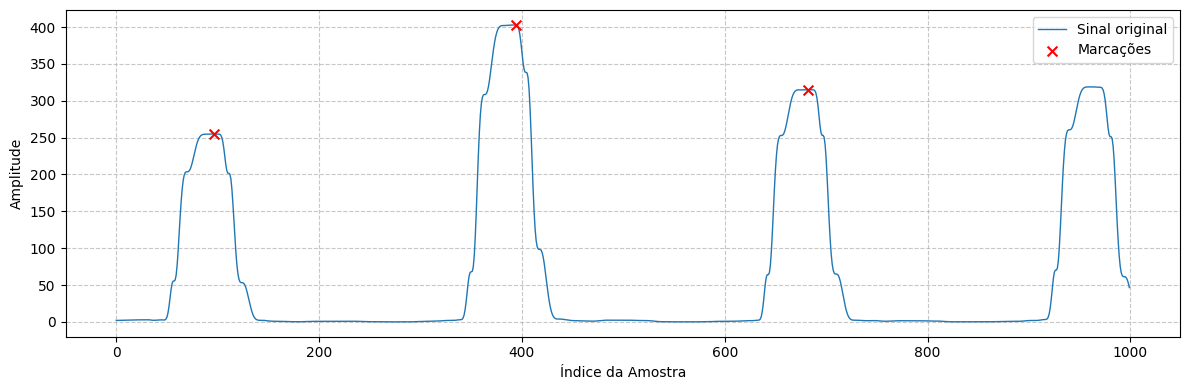

In [7]:
target_subject = subjects[0]
target_indices = detected_indices[0]

def plot_pt_steps(raw_signal, filtered_signal, derivated_signal, squared_signal, integrated_signal, fs=360, time=5):
    num_samples = time * fs
    time_axis = np.arange(num_samples) / fs

    plt.figure(1, figsize=(10, 4))
    plt.plot(time_axis, raw_signal[:num_samples], color='black')
    plt.title('Sinal Original')
    plt.ylabel('Amplitude')
    plt.xlabel('Tempo (s)')
    plt.tight_layout()

    plt.figure(2, figsize=(10, 4))
    plt.plot(time_axis, filtered_signal[:num_samples], color='blue')
    plt.title('Filtro Passa-Faixa')
    plt.ylabel('Amplitude')
    plt.xlabel('Tempo (s)')
    plt.tight_layout()

    plt.figure(3, figsize=(10, 4))
    plt.plot(time_axis, derivated_signal[:num_samples], color='green')
    plt.title('Derivação Causal')
    plt.ylabel('Amplitude')
    plt.xlabel('Tempo (s)')
    plt.tight_layout()

    plt.figure(4, figsize=(10, 4))
    plt.plot(time_axis, squared_signal[:num_samples], color='orange')
    plt.title('Transformação Não-Linear (Quadrado)')
    plt.ylabel('Amplitude')
    plt.xlabel('Tempo (s)')
    plt.tight_layout()

    plt.figure(5, figsize=(10, 4))
    plt.plot(time_axis, integrated_signal[:num_samples], color='red')
    plt.title('Integração por Janela Móvel')
    plt.ylabel('Amplitude')
    plt.xlabel('Tempo (s)')
    plt.tight_layout()
    plt.show()

def plotar_marcacoes(sinal, indices):
    plt.figure(figsize=(12, 4))
    plt.plot(sinal, color='#1f77b4', label='Sinal original', linewidth=1)

    indices_validos = [i for i in indices if i < len(sinal)]
    amplitudes = [sinal[i] for i in indices_validos]

    plt.scatter(indices_validos, amplitudes, color='red', marker='x', s=50, label='Marcações', zorder=3)
    plt.xlabel('Índice da Amostra')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plotar_marcacoes(target_subject.integrated_signal[:1000, 0], target_indices[:3])

##### Post-Processing


In [ ]:
real_peaks = align_peaks(target_indices, target_subject.raw_signal[:, 0], fs=target_subject.fs)
print(target_subject.annotations.sample[1:], target_subject.annotations.sample[1:].shape)
print(real_peaks, real_peaks.shape)

[    77    370    662 ... 649484 649734 649991] (2273,)
[    94    388    680 ... 649249 649502 649751] (2272,)


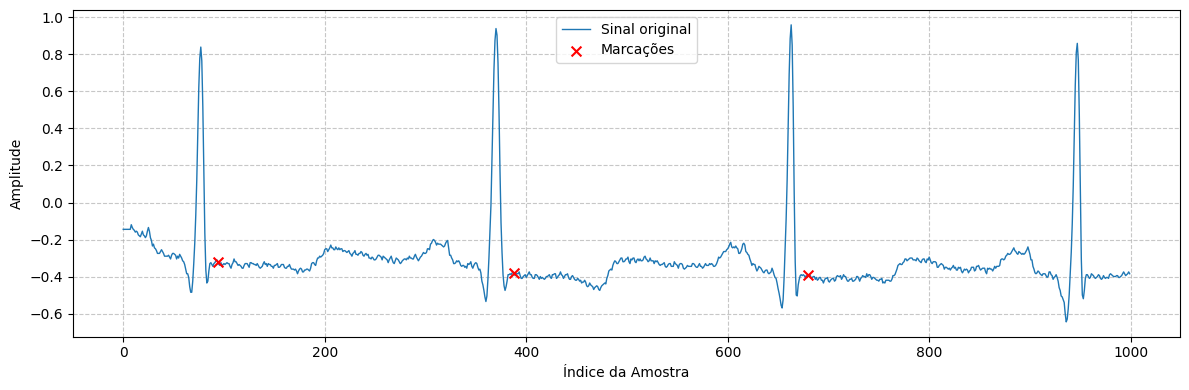

In [9]:
plotar_marcacoes(target_subject.raw_signal[:1000, 0], real_peaks[:3])

Alguns picos naturalmente não vão ser detectados pelo algoritmo de Pan-Tompkins. Por isso, é necessário fazer a distinção de quais picos foram realmente detectados e quais não foram.

Para isso colocamos um período de 150ms entre um pico real e um pico detectado. Se ele não estiver neste intervalo podemos considerá-lo um falso positivo.


In [10]:
synced_r_peaks_indices, synced_integrated_peaks_indices, synced_labels = synchronize_peaks(
    annotated_peaks=target_subject.annotations.sample,
    labels=target_subject.annotations.symbol,
    detected_r_peaks=real_peaks,
    detected_int_peaks=target_indices,
    fs=target_subject.fs,
)
len(synced_r_peaks_indices), len(synced_labels)

(2272, 2272)

Windowing


In [11]:
# TODO: single-channel ([:, 0]) is temporary; train/evaluate ML on both ECG channels later.
window_manager = WindowManager(
    synced_filtered_peaks=synced_r_peaks_indices,
    synced_labels=synced_labels,
    synced_integrated_peaks=synced_integrated_peaks_indices,
    integrated_signal=target_subject.integrated_signal[:, 0],
    filtered_signal=target_subject.filtered_signal[:, 0],
    window_span_ms=400,
    fs=target_subject.fs,
)
len(window_manager.filtered_r_peaks_windows)

2272

Feature extraction


In [12]:
templates = initialize_templates(window_manager.filtered_r_peaks_windows)
templates[0].shape

(144,)

In [13]:
beat_idx = 6
beat_features = extract_beat_features(
    window=window_manager.filtered_r_peaks_windows[beat_idx],
    templates=templates,
    prev_peak_idx=synced_r_peaks_indices[beat_idx - 1],
    peak_idx=synced_r_peaks_indices[beat_idx],
    fs=target_subject.fs,
    integrated_window=window_manager.integrated_r_peaks_windows[beat_idx],
)
tmpl_feats = extract_template_features(
    window_manager.filtered_r_peaks_windows[beat_idx], templates
)
prev_features = extract_beat_features(
    window=window_manager.filtered_r_peaks_windows[beat_idx - 1],
    templates=templates,
    prev_peak_idx=synced_r_peaks_indices[beat_idx - 2],
    peak_idx=synced_r_peaks_indices[beat_idx - 1],
    fs=target_subject.fs,
    integrated_window=window_manager.integrated_r_peaks_windows[beat_idx - 1],
)
beat_class = classify_beat(
    qrs_width_ms=beat_features["qrs_width_ms"],
    rr_ms=beat_features["rr_ms"],
    prev_rr_ms=prev_features["rr_ms"],
    **tmpl_feats,
)
beat_features, beat_class

({'ardiff': 0.12138636442790451,
  'maxcorr': 0.9976540431293153,
  'rr_ms': 819.4444444444445,
  'qrs_width_ms': 25.97222222222222},
 BeatClassification(waveform=<WaveformClass.PVC: 'pvc'>, rhythm=<RhythmClass.NONE: 'none'>, maxcorr_t1=0.9953030888398753, maxcorr_t2=0.9976540431293153, ardiff_t1=0.12138636442790451, ardiff_t2=0.2059256812295037, qrs_width_ms=25.97222222222222, rr_ms=819.4444444444445))

In [14]:
adapted_templates, beat_classes, n_updates = classify_and_adapt(
    window_manager.filtered_r_peaks_windows,
    templates,
    synced_r_peaks_indices,
    target_subject.fs,
    integrated_windows=window_manager.integrated_r_peaks_windows,
)
n_updates, beat_classes[0], adapted_templates[0].shape

(0,
 BeatClassification(waveform=<WaveformClass.PVC: 'pvc'>, rhythm=<RhythmClass.NONE: 'none'>, maxcorr_t1=0.9953030888398753, maxcorr_t2=0.9976540431293153, ardiff_t1=0.12138636442790451, ardiff_t2=0.2059256812295037, qrs_width_ms=25.97222222222222, rr_ms=819.4444444444445),
 (144,))

# Model evaluation

In [15]:
subject_eval = evaluate_subject(target_subject)
subject_summary = aggregate_evaluations([subject_eval])

print(f"Record {subject_eval.record_id}: {subject_eval.n_classified} beats classified")
print(f"Synced {subject_eval.n_detected_synced}/{subject_eval.n_annotated} annotations")
display(general_confusion_matrix(subject_summary))
display(format_classification_metrics(subject_summary))


Record 100: 2266 beats classified
Synced 2272/2274 annotations


predicted,abnormal,normal
reference,,
abnormal,7,27
normal,346,1886


,metric,value
0,Accuracy,83.54%
1,Precision,1.98%
2,Recall,20.59%
3,Sensitivity,20.59%
4,Specificity,84.50%
5,Detected beats,99.91%
6,True Positive,7
7,True Negative,1886
8,False Positive,346
9,False Negative,27


In [16]:
all_evals = evaluate_subjects(subjects)
full_summary = aggregate_evaluations(all_evals)

print(
    f"Records: {full_summary['n_records']} | "
    f"skipped: {full_summary['n_skipped']} | "
    f"template failed: {full_summary['n_template_failed']}"
)
display(general_confusion_matrix(full_summary))
display(format_classification_metrics(full_summary))
print(f"Median FN per record: {median_fn_per_record(all_evals):.0f}")


Records: 39 | skipped: 9 | template failed: 0


predicted,abnormal,normal
reference,,
abnormal,7144,4852
normal,18845,57208


,metric,value
0,Accuracy,73.09%
1,Precision,27.49%
2,Recall,59.55%
3,Sensitivity,59.55%
4,Specificity,75.22%
5,Detected beats,95.46%
6,True Positive,7144
7,True Negative,57208
8,False Positive,18845
9,False Negative,4852


Median FN per record: 14


### Subamostragem
